# 01 - Exploratory Data Analysis + Baseline
**Stage 4 of the SOC-Copilot project.**

This notebook:
1. Loads the synthetic authentication-event dataset produced by `data/generate.py`.
2. Inspects its structure, class balance, and the feature distributions that separate benign from attack events.
3. Fits a **supervised baseline** (Logistic Regression on the labelled data).
   The baseline gives us a *ceiling*: it is what a model could do if it had labels.
   The Isolation Forest in notebook 02 will have to earn its keep against this number while training on **only the benign rows**.

> The goal of Stage 4 is to *understand* the data and to set a benchmark, not to ship the production model.


In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd() / "Project"
DATA_CSV = PROJECT_ROOT / "data" / "soc_events.csv"
print("Loading:", DATA_CSV)
df = pd.read_csv(DATA_CSV)
df.head()

Loading: /mnt/c/Users/stav/Desktop/cyber course/HIT-ai-cybersecurity/Project/data/soc_events.csv


,timestamp,user,source_ip,service,protocol,success,failed_attempts_5min,bytes_sent,session_duration_ms,user_is_known,ip_is_known,hour,is_anomaly,attack_label
0,2024-10-08T22:12:42,olivia,10.20.191.7,vpn,udp1194,1,0,4568,278417,1,1,22,0,NaN
1,2024-10-12T13:11:19,laura,10.20.72.177,rdp,tcp3389,0,1,4585,171742,1,1,13,0,NaN
2,2024-10-08T16:47:11,olivia,10.20.60.248,webapp,tcp443,1,0,3821,1000,1,1,16,0,NaN
3,2024-10-11T03:16:44,administrator,45.83.64.219,ssh,tcp22,0,35,194,1677,1,0,3,1,T1110.001
4,2024-10-10T13:00:31,niaj,10.20.159.237,rdp,tcp3389,1,0,3524,115725,1,1,13,0,NaN


## 1. Dataset shape & class balance

The generator targets a 3 % contamination ratio split across three MITRE techniques.
That gives us a realistic, imbalanced detection problem - the kind of class skew a SOC actually sees.

In [2]:
print(f"Total events: {len(df):,}")
print(f"Columns:      {list(df.columns)}")
print()
print("Class balance:")
print(df.attack_label.replace('', 'benign').value_counts())
print()
print(f"Overall anomaly rate: {df.is_anomaly.mean():.2%}")

Total events: 10,000
Columns:      ['timestamp', 'user', 'source_ip', 'service', 'protocol', 'success', 'failed_attempts_5min', 'bytes_sent', 'session_duration_ms', 'user_is_known', 'ip_is_known', 'hour', 'is_anomaly', 'attack_label']

Class balance:
attack_label
T1110.001    157
T1110.003     93
T1078         50
Name: count, dtype: int64

Overall anomaly rate: 3.00%


## 2. Feature distributions - benign vs anomalous

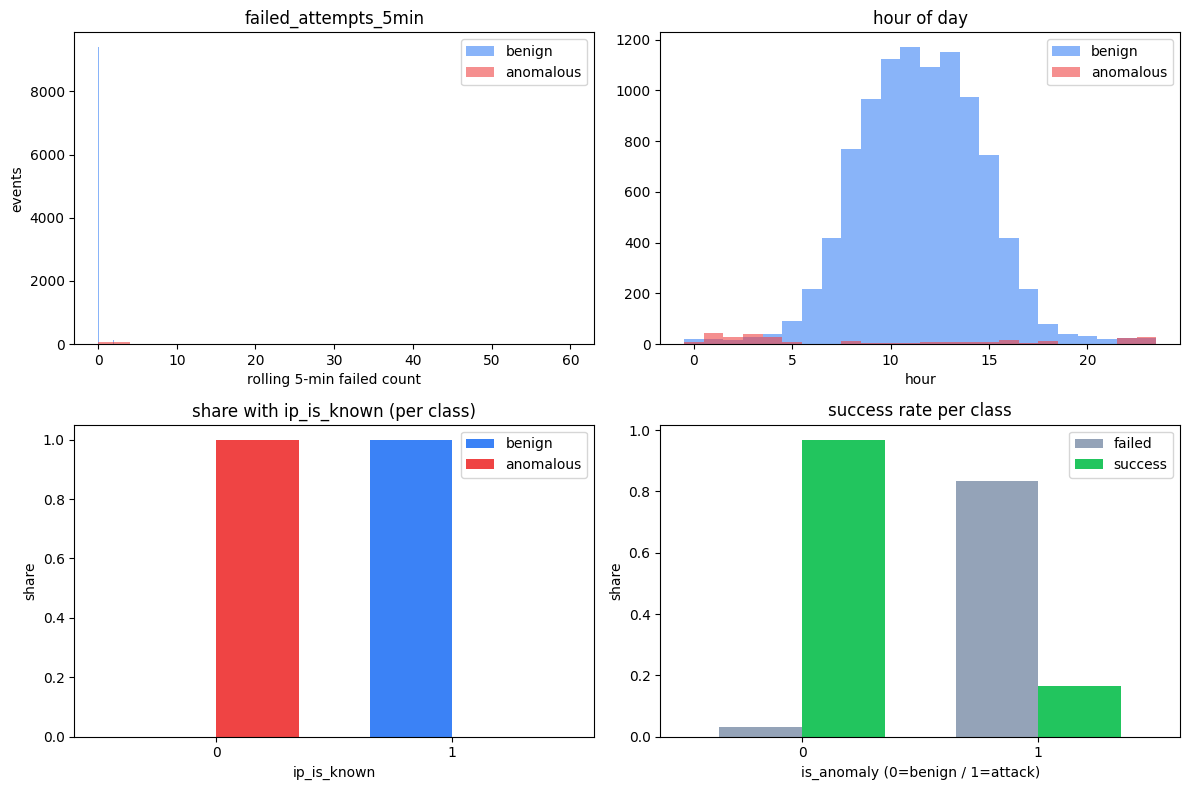

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (a) failed_attempts_5min: should separate brute force from everything else
ax = axes[0, 0]
ax.hist(df.loc[df.is_anomaly == 0, "failed_attempts_5min"], bins=30,
        alpha=0.6, label="benign", color="#3b82f6")
ax.hist(df.loc[df.is_anomaly == 1, "failed_attempts_5min"], bins=30,
        alpha=0.6, label="anomalous", color="#ef4444")
ax.set_title("failed_attempts_5min")
ax.set_xlabel("rolling 5-min failed count"); ax.set_ylabel("events")
ax.legend()

# (b) hour-of-day: anomalies cluster in off-hours
ax = axes[0, 1]
bins = np.arange(0, 25) - 0.5
ax.hist(df.loc[df.is_anomaly == 0, "hour"], bins=bins, alpha=0.6, label="benign", color="#3b82f6")
ax.hist(df.loc[df.is_anomaly == 1, "hour"], bins=bins, alpha=0.6, label="anomalous", color="#ef4444")
ax.set_title("hour of day"); ax.set_xlabel("hour"); ax.legend()

# (c) ip_is_known
ax = axes[1, 0]
ct = pd.crosstab(df.ip_is_known, df.is_anomaly, normalize="columns")
ct.plot(kind="bar", ax=ax, color=["#3b82f6", "#ef4444"], width=0.7)
ax.set_title("share with ip_is_known (per class)")
ax.set_xlabel("ip_is_known"); ax.set_ylabel("share"); ax.legend(["benign", "anomalous"])
ax.tick_params(axis="x", rotation=0)

# (d) success rate per class
ax = axes[1, 1]
ct = pd.crosstab(df.is_anomaly, df.success, normalize="index")
ct.plot(kind="bar", ax=ax, color=["#94a3b8", "#22c55e"], width=0.7)
ax.set_title("success rate per class")
ax.set_xlabel("is_anomaly (0=benign / 1=attack)"); ax.set_ylabel("share")
ax.legend(["failed", "success"])
ax.tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()

**Reading the panels:**

- *failed_attempts_5min*: T1110.001 brute-force events live in the tail >= 10. T1110.003 spraying and T1078 valid-account abuse are invisible on this feature alone - that is why no single feature is sufficient.
- *hour of day*: anomalies bias toward 22-05, but spraying happens in business hours, so this feature alone over-fires on legitimate night-shift users.
- *ip_is_known*: every attack event has `ip_is_known = 0`. This is the single strongest feature - but normal events can also come from never-before-seen IPs (new contractor, hotel WiFi).
- *success*: T1078 events are *successful* logins, so a naive "alert only on failures" rule misses them entirely.

This is exactly why we need a model that combines all the features rather than per-feature thresholds.

## 3. Supervised baseline - Logistic Regression

A SOC analyst, given labels, could reach a certain F1 with a simple linear classifier.
Our unsupervised model has to compete with that number without using labels.


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

FEATURES = [
    "hour", "failed_attempts_5min", "success",
    "bytes_sent", "session_duration_ms",
    "user_is_known", "ip_is_known",
]
# one-hot the service column
X_df = pd.concat([df[FEATURES], pd.get_dummies(df.service, prefix="svc")], axis=1)
y    = df.is_anomaly.values

X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
clf.fit(X_train_s, y_train)

y_pred = clf.predict(X_test_s)
print(classification_report(y_test, y_pred, target_names=["benign", "anomalous"], digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(f"F1 (anomalous class): {f1_score(y_test, y_pred):.3f}")

              precision    recall  f1-score   support

      benign      1.000     1.000     1.000      2425
   anomalous      1.000     1.000     1.000        75

    accuracy                          1.000      2500
   macro avg      1.000     1.000     1.000      2500
weighted avg      1.000     1.000     1.000      2500

Confusion matrix:
[[2425    0]
 [   0   75]]

F1 (anomalous class): 1.000


## 4. Takeaways for Stage 5

- The dataset is small enough to load into memory, large enough that detection is non-trivial.
- The three attack profiles map onto three different feature signatures, so a multi-feature model is required.
- The supervised baseline gives us a **ceiling F1** that the unsupervised Isolation Forest will have to approach.
- *No single feature is a clean classifier* - `ip_is_known` is the strongest one but still has false positives (new partners, contractors).

Continue in **`02_isolation_forest.ipynb`**.